In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [116]:
#lets create synthetic data points
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

In [117]:
#x,y

<Axes: xlabel='0', ylabel='1'>

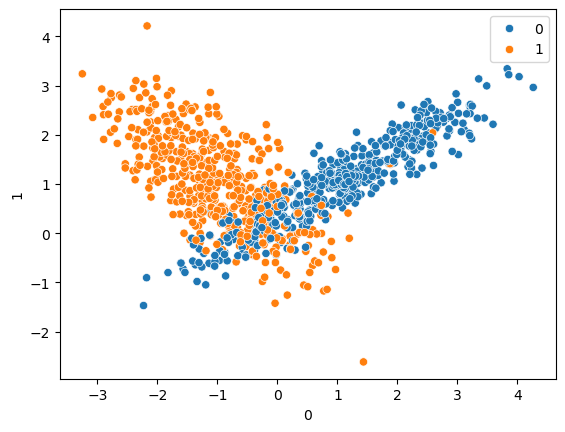

In [118]:
#df=pd.DataFrame(x)
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)


In [119]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=43)

In [120]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [121]:
#prediction
y_pred=svc.predict(x_test)

In [122]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[101  25]
 [ 18 106]]
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       126
           1       0.81      0.85      0.83       124

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250



In [123]:
#RBF kernel
rbf=SVC(kernel='rbf')
rbf.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [124]:
#prediction
y_pred1=rbf.predict(x_test)

In [125]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[111  15]
 [ 14 110]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       126
           1       0.88      0.89      0.88       124

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250



In [126]:
#polynomial kernel
poly=SVC(kernel='poly')
poly.fit(x_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [127]:
#prediction
y_pred2=poly.predict(x_test)

In [128]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

[[126   0]
 [ 38  86]]
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       126
           1       1.00      0.69      0.82       124

    accuracy                           0.85       250
   macro avg       0.88      0.85      0.84       250
weighted avg       0.88      0.85      0.84       250



In [129]:
#Hyperparameter Tunning
param_grid={'C':[0.1,1,10,100,1000],
           'gamma':[1,0.1,0.01,0.001,0.0001],
           'kernel':['rbf']}


In [130]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)

In [131]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.847 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.833 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.827 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.800 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.853 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.820 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [134]:
grid.best_params_

{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

In [135]:
y_pred4=rbf.predict(x_test)
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

[[111  15]
 [ 14 110]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       126
           1       0.88      0.89      0.88       124

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250



In [136]:
#support vector Regression

In [137]:
##dataset(tips dataset)
import seaborn as sns
df=sns.load_dataset('tips')

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [139]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [140]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [141]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [142]:
#inependent and independent
x=df[[ 'tip', 'sex', 'smoker', 'day', 'time', 'size']]
y=df['total_bill']

In [143]:
##train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)

In [144]:
## feature encoding (label encoding and one hot encoding)
from sklearn.preprocessing import LabelEncoder

In [145]:
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()

In [146]:
import warnings
x_train['sex']=le1.fit_transform(x_train['sex'])
x_train['smoker']=le2.fit_transform(x_train['smoker'])
x_train['time']=le3.fit_transform(x_train['time'])

In [147]:
x_train.head()

,tip,sex,smoker,day,time,size
58,1.76,1,1,Sat,0,2
1,1.66,1,0,Sun,0,3
2,3.50,1,0,Sun,0,3
68,2.01,1,0,Sat,0,2
184,3.00,1,1,Sun,0,2


In [148]:
x_test['sex']=le1.fit_transform(x_test['sex'])
x_test['smoker']=le2.fit_transform(x_test['smoker'])
x_test['time']=le3.fit_transform(x_test['time'])

In [149]:
x_test.head()

,tip,sex,smoker,day,time,size
162,2.00,0,0,Sun,0,3
60,3.21,1,1,Sat,0,2
61,2.00,1,1,Sat,0,2
63,3.76,1,1,Sat,0,4
69,2.09,1,1,Sat,0,2


In [150]:
## one hot encoding-- ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [151]:
ct=ColumnTransformer(transformers=[('onehot',OneHotEncoder(drop='first'),['sex','smoker','day','time'])],
                                  remainder='passthrough')

In [152]:
import sys
np.set_printoptions(threshold=sys.maxsize)
x_train2=ct.fit_transform(x_train)
x_test2=ct.transform(x_test)

In [154]:
#x_test2

In [156]:
#SVR
from sklearn.svm import SVR
svr=SVR()

In [157]:
svr.fit(x_train2,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [158]:
y_pred=svr.predict(x_test2)

In [160]:
from sklearn.metrics import mean_absolute_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.4602811456115927
4.1486423210190235


In [161]:
#hyperparameter tunning 
param_grid={'C':[0.1,1,10,100,1000],
           'gamma':[1,0.1,0.01,0.001,0.0001],
           'kernel':['rbf']}

In [164]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)
grid.fit(x_train2,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ..........C=0.1, gamma=1, kernel=rbf;, score=nan total time=   0.0s
[CV 2/5] END ..........C=0.1, gamma=1, kernel=rbf;, score=nan total time=   0.0s
[CV 3/5] END ..........C=0.1, gamma=1, kernel=rbf;, score=nan total time=   0.0s
[CV 4/5] END ..........C=0.1, gamma=1, kernel=rbf;, score=nan total time=   0.0s
[CV 5/5] END ..........C=0.1, gamma=1, kernel=rbf;, score=nan total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=0.1, kernel=rbf;, score=nan total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=0.1, kernel=rbf;, score=nan total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=0.1, kernel=rbf;, score=nan total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=0.1, kernel=rbf;, score=nan total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=0.1, kernel=rbf;, score=nan total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=0.01, kernel=rbf;, score=nan total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=0.01, kernel=r

ValueError: 
All the 125 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\svm\_base.py", line 207, in fit
    y = self._validate_targets(y)
  File "C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\svm\_base.py", line 747, in _validate_targets
    check_classification_targets(y)
    ~~~~~~